  FERMENTATION PID TEMPERATURE CONTROL — 1st Order
  u_bias = 8 L/hr
  Kr     = 0.015 m³/hr·°C  (15 L/hr/°C)
  tauI   = 30.0 hr
  tauD   = 2.0 hr
  F_coolant in [1, 100] L/hr
  Disturbance: +3.0 °C at t = 134.4 h

Running 1st-order simulation ...
  Complete

─── Performance metrics ─────────────────────────────────
  IAE full run              : 718.3 °C·hr
  IAE active ferm (t<150h)  : 199.0 °C·hr
  IAE post-ferm  (t>150h)   : 519.1 °C·hr  [no heater — unavoidable]
  Max overshoot (above set) : 10.15 °C
  Max undershoot (below set): 3.99 °C
  Post-disturbance max dev  : 2.19 °C
  Mean F_coolant            : 17.9 L/hr
  Max  F_coolant            : 100.0 L/hr



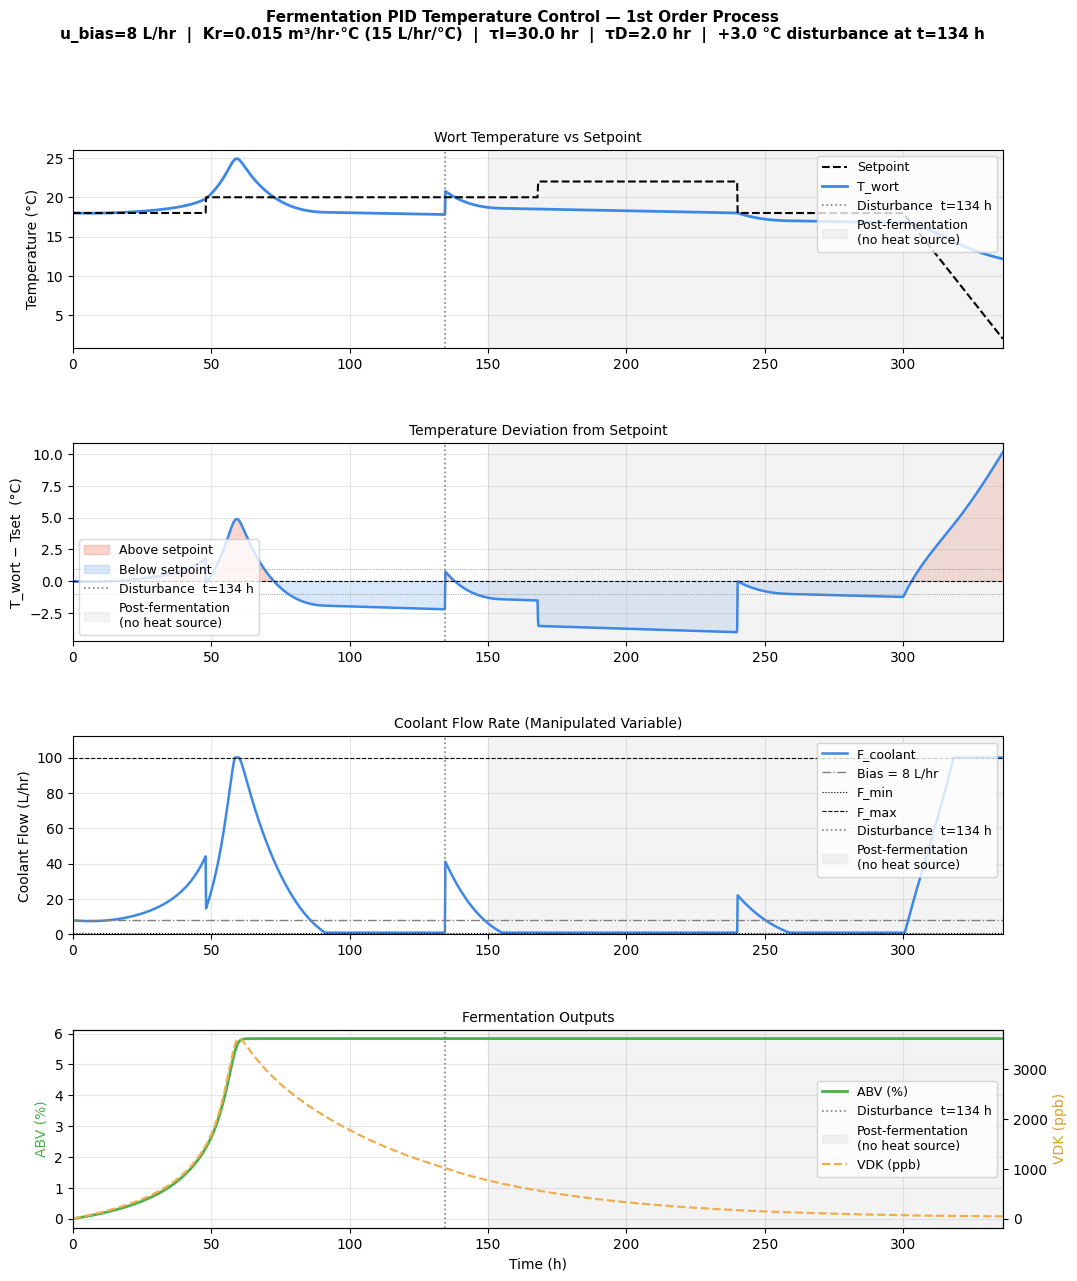

─── Simulation complete ─────────────────────────────────


In [0]:
# ============================================================
#  FERMENTATION HEAT BALANCE — PID TEMPERATURE CONTROL
#  1st-order process (quasi-steady-state jacket)
#
#  Controlled variable  : Wort temperature  (T_wort)
#  Manipulated variable : Coolant flow rate (F_coolant_m3h)
#  Disturbance          : +3 °C step at t = 40% of run (134.4 h)
#
#  PID law (e = T - Tset, derivative on measurement, anti-windup):
#    u(t) = u_bias + Kr*e(t) + (Kr/tauI)*I(t) + Kr*tauD*dT/dt
#    dI/dt = e(t)   [frozen at saturation]
#
#  Controller sizing rationale:
#    - Peak fermentation exotherm requires F ~ 88 L/hr to hold setpoint
#    - At that peak the error is ~6 °C without cooling
#    - Proportional band: Kr = (F_max - u_bias) / e_full
#                            = (100 - 8) / 6 = 15.3 L/hr per °C
#    - Previous Kr = 4 L/hr/°C only produced ~32 L/hr at peak error
#      → wort overshot by 7+ °C. Kr must be ~15 L/hr/°C.
#
#  Physical limitation (unavoidable):
#    Once fermentation sugar is depleted (~t > 150 h), the wort has
#    NO internal heat source and drifts toward the inlet coolant
#    temperature (10 °C). There is no heater, so the controller
#    cannot maintain setpoint in this late phase — it can only
#    reduce flow to F_min and slow the natural cooling.
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────────────────────
#  WORT TEMPERATURE SETPOINT
# ─────────────────────────────────────────────────────────────
duration = 336          # hr  (14 days)
t_base   = np.linspace(0, duration, 3000)

Tset_arr = np.zeros(len(t_base))
for i, ti in enumerate(t_base):
    if   ti < 48:   Tset_arr[i] = 18
    elif ti < 168:  Tset_arr[i] = 20
    elif ti < 240:  Tset_arr[i] = 22
    elif ti < 300:  Tset_arr[i] = 18
    else:           Tset_arr[i] = 18 - (16/36) * (ti - 300)

Tset_func = interp1d(t_base, Tset_arr, fill_value="extrapolate")

# ─────────────────────────────────────────────────────────────
#  DISTURBANCE  (+3 °C step injected directly into wort state)
# ─────────────────────────────────────────────────────────────
t_disturbance  = 0.40 * duration    # 134.4 h
disturbance_dT = 3.0                # °C

# ─────────────────────────────────────────────────────────────
#  PHYSICAL & FERMENTATION PROPERTIES
# ─────────────────────────────────────────────────────────────
ethanol_density   = 789
water_density_ref = 1000
OG                = 1.048
yeast_pitch_rate  = 0.75
yeast_density     = 40e-12

volume           = 1200      # L  wort
vessel_volume_m3 = 1.500     # m³
temperature      = 18        # °C  initial
temperature_K    = temperature + 273.15

k_s   = 15.3;  k_e  = 6.31;  S_min = 13.1
g_x   = 0.0167; k_v = 0.651; k_co2 = 3.71
a_MB  = 0.4;   b_MB = -1.1;  c_MB  = 0.025; d_MB = -0.056

degP           = (-616.868) + (1111.14*OG) - (630.272*OG**2) + (135.997*OG**3)
wort_density_MB = OG * water_density_ref
s_calc          = (degP/100) * wort_density_MB
yeast_req       = yeast_pitch_rate * (volume * 1000) * degP * 1e6
yeast_conc      = (yeast_req * yeast_density) / volume

T_water_in_K  = 283.15        # 10 °C  inlet coolant
water_density = (999.80 + 992.30) / 2
water_Cp      = 4.1789         # kJ/kg K
wort_density  = (1048 + 1005) / 2
wort_Cp       = 4.0585         # kJ/kg K

U_hr    = 50 * 3600            # J/m² K hr
delta_H = -587                 # kJ/kg substrate
Area    = 0.3 * 14.137 / 2    # m²
V_wort_m3 = volume / 1000
V_jacket  = vessel_volume_m3 * 0.05   # 75 L jacket

# ─────────────────────────────────────────────────────────────
#  PID CONTROLLER PARAMETERS
#
#  Sizing: peak exotherm needs F ~ 88 L/hr at e ~ 6 °C
#    Kr = (F_max - u_bias) / e_full = (100 - 8) / 6 ≈ 15 L/hr/°C
#  tauI long (30 hr) to avoid integral windup during exotherm
#  tauD moderate (2 hr) to anticipate fast exotherm ramp
# ─────────────────────────────────────────────────────────────
u_bias = 0.008          # m³/hr  (8 L/hr nominal bias)
Kr     = 0.015          # m³/hr·°C  (15 L/hr/°C)
tauI   = 30.0           # hr  (long — prevents windup)
tauD   = 2.0            # hr

F_min  = 0.001          # m³/hr  (1 L/hr minimum)
F_max  = 0.10           # m³/hr  (100 L/hr maximum)

print("=" * 60)
print("  FERMENTATION PID TEMPERATURE CONTROL — 1st Order")
print("=" * 60)
print(f"  u_bias = {u_bias*1000:.0f} L/hr")
print(f"  Kr     = {Kr} m³/hr·°C  ({Kr*1000:.0f} L/hr/°C)")
print(f"  tauI   = {tauI} hr")
print(f"  tauD   = {tauD} hr")
print(f"  F_coolant in [{F_min*1000:.0f}, {F_max*1000:.0f}] L/hr")
print(f"  Disturbance: +{disturbance_dT} °C at t = {t_disturbance:.1f} h\n")

# ─────────────────────────────────────────────────────────────
#  BIOMASS GROWTH RATE
# ─────────────────────────────────────────────────────────────
def mu_x(s, S_min, mu_max_T):
    return mu_max_T * (1 - S_min / s) if s >= S_min else 0.0

# ─────────────────────────────────────────────────────────────
#  PID COOLANT FLOW  —  returns (F_clamped, at_saturation)
#  Derivative on measurement only (no setpoint kick).
# ─────────────────────────────────────────────────────────────
def pid_flow(T_K, dT_dt, I_pid, t):
    e   = (T_K - 273.15) - Tset_func(t)
    u   = (u_bias
           + Kr   * e
           + (Kr / tauI) * I_pid
           + Kr * tauD * dT_dt)
    u_c = float(np.clip(u, F_min, F_max))
    return u_c, (u_c != u)

# ─────────────────────────────────────────────────────────────
#  ODE — 1st ORDER PROCESS  (quasi-steady-state jacket)
#  States: [x, s, e_ferm, co2, vdk, T_wort_K, I_pid]
# ─────────────────────────────────────────────────────────────
def ODE_1st(t, state):
    x, s, e_ferm, co2, vdk, T, I_pid = state

    T_C      = T - 273.15
    mu_max_T = a_MB * np.log(T_C) + b_MB
    r_vdk_T  = c_MB * np.log(T_C) + d_MB
    mu       = mu_x(s, S_min, mu_max_T)

    dx_dt   = (mu * x) - (g_x * x)
    ds_dt   = -k_s * mu * x
    de_dt   =  k_e * mu * x
    dco2_dt =  k_co2 * mu * x
    dvdk_dt =  k_v * mu * x - r_vdk_T * vdk

    UA_jk   = Area * U_hr / (V_jacket * water_density * water_Cp * 1000)
    UA_wort = Area * U_hr / (V_wort_m3 * wort_density * wort_Cp * 1000)

    # First-pass dT_dt estimate (dT≈0) to get F, then recompute Tc
    F_cool, sat = pid_flow(T, 0.0, I_pid, t)
    Tc    = ((F_cool / V_jacket) * T_water_in_K + UA_jk * T) / (F_cool / V_jacket + UA_jk)
    dT_dt = ((ds_dt * delta_H / (wort_density * wort_Cp))
             - UA_wort * (T - Tc))

    # Anti-windup: freeze integral when output is saturated
    dI_dt = 0.0 if sat else (T_C - Tset_func(t))

    return [dx_dt, ds_dt, de_dt, dco2_dt, dvdk_dt, dT_dt, dI_dt]

# ─────────────────────────────────────────────────────────────
#  TWO-SEGMENT SIMULATION
# ─────────────────────────────────────────────────────────────
def run_simulation(ODE_func, y0):
    n1 = int(2000 * (t_disturbance / duration))
    n2 = 2000 - n1

    sol1 = solve_ivp(ODE_func, (0, t_disturbance), y0,
                     t_eval=np.linspace(0, t_disturbance, n1),
                     method='BDF', max_step=0.1, rtol=1e-5, atol=1e-7)
    if not sol1.success:
        raise RuntimeError(f"Segment 1 failed: {sol1.message}")

    y_d    = sol1.y[:, -1].copy()
    y_d[5] += disturbance_dT          # +3 K into T_wort (state index 5)

    sol2 = solve_ivp(ODE_func, (t_disturbance, duration), y_d,
                     t_eval=np.linspace(t_disturbance, duration, n2),
                     method='BDF', max_step=0.1, rtol=1e-5, atol=1e-7)
    if not sol2.success:
        raise RuntimeError(f"Segment 2 failed: {sol2.message}")

    t_out = np.concatenate([sol1.t,     sol2.t[1:]])
    y_out = np.concatenate([sol1.y,     sol2.y[:, 1:]], axis=1)
    return t_out, y_out

# ─────────────────────────────────────────────────────────────
#  RUN SIMULATION
# ─────────────────────────────────────────────────────────────
y0 = [yeast_conc, s_calc, 0.0, 0.0, 0.0, temperature_K, 0.0]

print("Running 1st-order simulation ...")
t_out, y_out = run_simulation(ODE_1st, y0)
print("  Complete\n")

# ─────────────────────────────────────────────────────────────
#  EXTRACT OUTPUTS
# ─────────────────────────────────────────────────────────────
T_C   = y_out[5] - 273.15
I_pid = y_out[6]
Tset  = Tset_func(t_out)
dev   = T_C - Tset

abv = (y_out[2] / ethanol_density) * 100
ppb = y_out[4] * 1000

F_lh = np.array([pid_flow(y_out[5, i], 0.0, I_pid[i], t_out[i])[0]
                 for i in range(len(t_out))]) * 1000   # L/hr

# ─────────────────────────────────────────────────────────────
#  PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────
i_d = np.searchsorted(t_out, t_disturbance)

# Split into active-fermentation (t<150h) and post-fermentation (t>150h)
i_150 = np.searchsorted(t_out, 150)

print("─── Performance metrics ─────────────────────────────────")
print(f"  IAE full run              : {np.trapezoid(np.abs(dev), t_out):.1f} °C·hr")
print(f"  IAE active ferm (t<150h)  : {np.trapezoid(np.abs(dev[:i_150]), t_out[:i_150]):.1f} °C·hr")
print(f"  IAE post-ferm  (t>150h)   : {np.trapezoid(np.abs(dev[i_150:]), t_out[i_150:]):.1f} °C·hr  [no heater — unavoidable]")
print(f"  Max overshoot (above set) : {max(0, dev.max()):.2f} °C")
print(f"  Max undershoot (below set): {abs(min(0, dev.min())):.2f} °C")
print(f"  Post-disturbance max dev  : {np.abs(dev[i_d:i_d+200]).max():.2f} °C")
print(f"  Mean F_coolant            : {np.mean(F_lh):.1f} L/hr")
print(f"  Max  F_coolant            : {np.max(F_lh):.1f} L/hr")
print()

# ─────────────────────────────────────────────────────────────
#  PLOTS
# ─────────────────────────────────────────────────────────────
col_T    = '#3C88E8'
col_set  = 'black'
col_dist = 'grey'
col_noh  = '#dddddd'   # shade for no-heater region

fig = plt.figure(figsize=(12, 14))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.48)

fig.suptitle(
    "Fermentation PID Temperature Control — 1st Order Process\n"
    f"u_bias={u_bias*1000:.0f} L/hr  |  Kr={Kr} m³/hr·°C ({Kr*1000:.0f} L/hr/°C)"
    f"  |  τI={tauI} hr  |  τD={tauD} hr  |  "
    f"+{disturbance_dT} °C disturbance at t={t_disturbance:.0f} h",
    fontsize=11, fontweight='bold'
)

# Time of sugar depletion (approximate — where ABV plateaus)
t_depletion = 150   # hr  (conservative estimate)

def vl(ax):
    ax.axvline(t_disturbance, color=col_dist, ls=':', lw=1.2,
               label=f'Disturbance  t={t_disturbance:.0f} h')
    ax.axvspan(t_depletion, duration, color=col_noh, alpha=0.35,
               label='Post-fermentation\n(no heat source)')
    ax.set_xlim(0, duration)
    ax.grid(True, alpha=0.3)

# ── Panel 1: Wort temperature ─────────────────────────────────
ax = fig.add_subplot(gs[0])
ax.plot(t_out, Tset, col_set, lw=1.5, ls='--', label='Setpoint', zorder=5)
ax.plot(t_out, T_C,  col_T,   lw=2.0, label='T_wort')
vl(ax)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Wort Temperature vs Setpoint", fontsize=10)
ax.legend(fontsize=9, loc='upper right')

# ── Panel 2: Temperature deviation ───────────────────────────
ax = fig.add_subplot(gs[1])
ax.plot(t_out, dev, col_T, lw=1.8)
ax.fill_between(t_out, dev, 0, where=(dev > 0), color='#E8593C', alpha=0.25, label='Above setpoint')
ax.fill_between(t_out, dev, 0, where=(dev < 0), color=col_T,    alpha=0.20, label='Below setpoint')
ax.axhline(0,  color='k',    lw=0.8, ls='--')
ax.axhline( 1, color='grey', lw=0.6, ls=':')
ax.axhline(-1, color='grey', lw=0.6, ls=':')
vl(ax)
ax.set_ylabel("T_wort − Tset  (°C)")
ax.set_title("Temperature Deviation from Setpoint", fontsize=10)
ax.legend(fontsize=9, loc='lower left')

# ── Panel 3: Coolant flow ─────────────────────────────────────
ax = fig.add_subplot(gs[2])
ax.plot(t_out, F_lh, col_T, lw=1.8, label='F_coolant')
ax.axhline(u_bias*1000, color='grey',  ls='-.', lw=1.0, label=f'Bias = {u_bias*1000:.0f} L/hr')
ax.axhline(F_min*1000,  color='black', ls=':',  lw=0.8, label='F_min')
ax.axhline(F_max*1000,  color='black', ls='--', lw=0.8, label='F_max')
vl(ax)
ax.set_ylabel("Coolant Flow (L/hr)")
ax.set_title("Coolant Flow Rate (Manipulated Variable)", fontsize=10)
ax.set_ylim(0, F_max*1000*1.12)
ax.legend(fontsize=9, loc='upper right')

# ── Panel 4: Fermentation outputs ────────────────────────────
ax = fig.add_subplot(gs[3])
ax2 = ax.twinx()
ax.plot( t_out, abv, '#4cae4c', lw=2.0, label='ABV (%)')
ax2.plot(t_out, ppb, '#f0ad4e', lw=1.6, ls='--', label='VDK (ppb)')
ax.set_xlabel("Time (h)")
ax.set_ylabel("ABV (%)", color='#4cae4c')
ax2.set_ylabel("VDK (ppb)", color='#d9a024')
ax.set_title("Fermentation Outputs", fontsize=10)
vl(ax)
ln1, lb1 = ax.get_legend_handles_labels()
ln2, lb2 = ax2.get_legend_handles_labels()
ax.legend(ln1+ln2, lb1+lb2, fontsize=9, loc='center right')

plt.savefig("Heat_Balance_PID_1st_Order.png", dpi=150, bbox_inches='tight')
plt.show()

print("─── Simulation complete ─────────────────────────────────")


Running sensitivity sweeps ...
  Kr = 0.004
  Kr = 0.01
  Kr = 0.015
  Kr = 0.025
  Kr = 0.04
  tauI = 6.0
  tauI = 15.0
  tauI = 30.0
  tauI = 60.0
  tauI = 120.0
  tauD = 0.0
  tauD = 1.0
  tauD = 2.0
  tauD = 4.0
  tauD = 8.0
  Done.



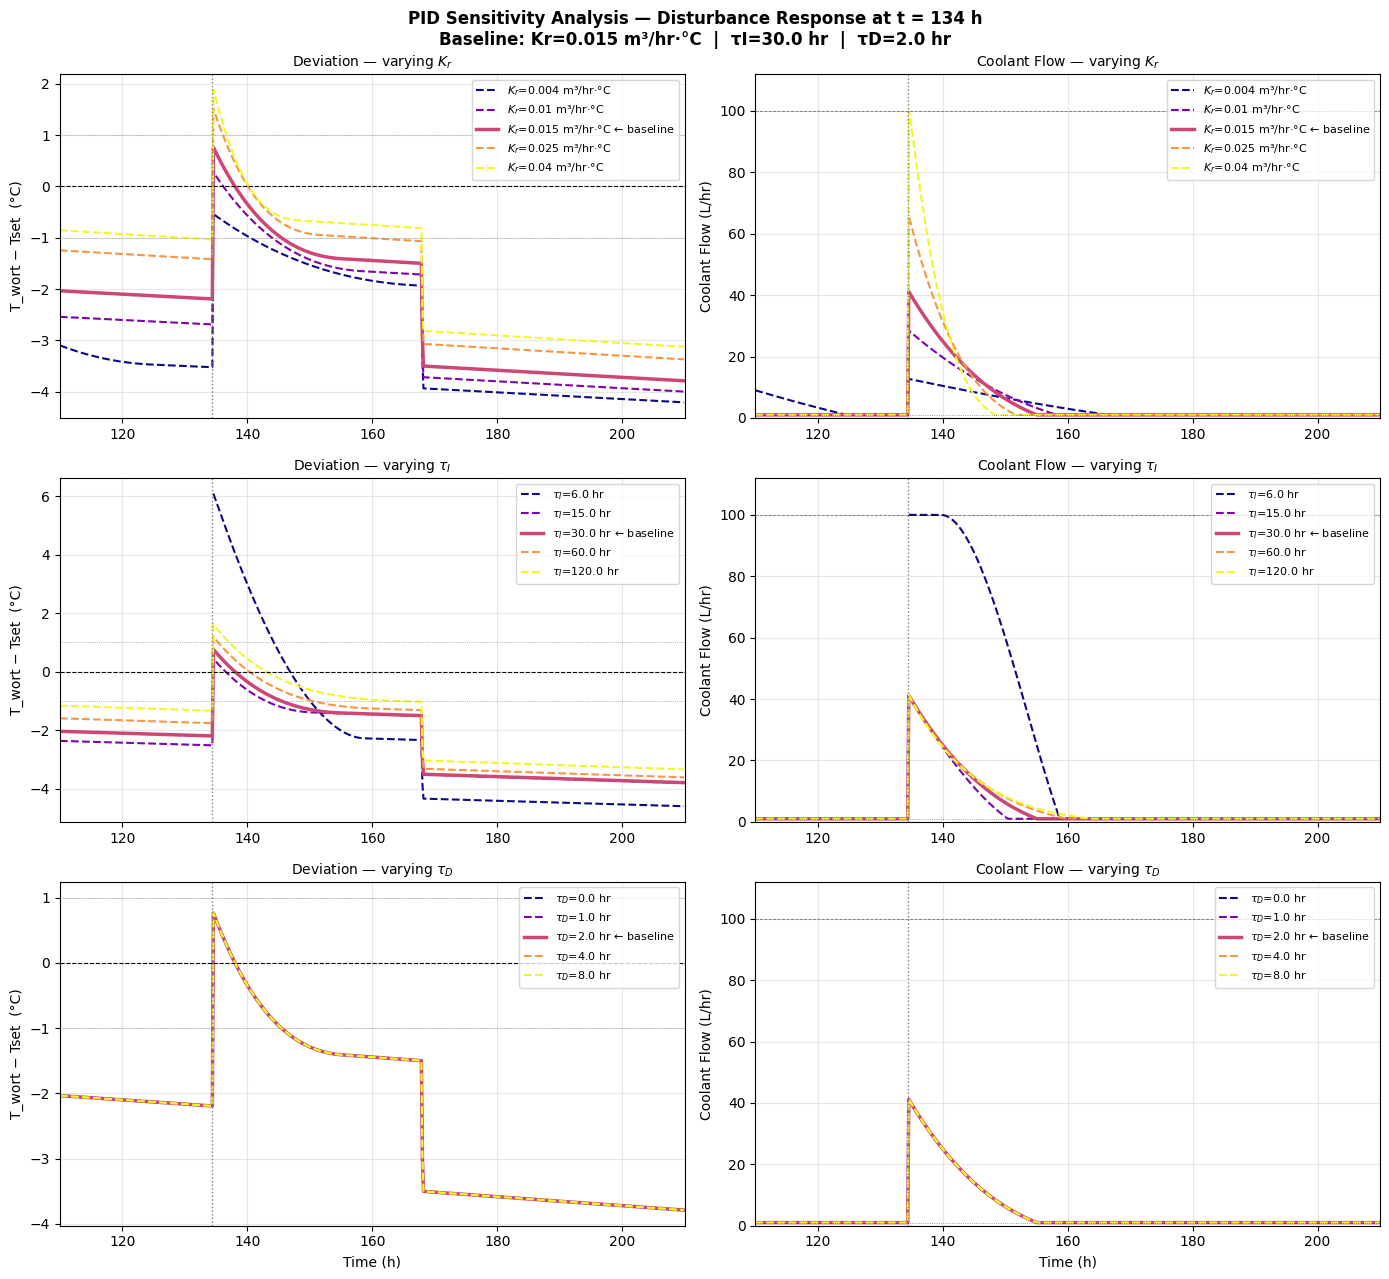

─── Sensitivity analysis complete ───────────────────────


In [0]:

# ═══════════════════════════════════════════════════════════════
#  SENSITIVITY ANALYSIS — Effect of Kr, tauI, tauD
#  Zoomed window: t = 110–200 h  (disturbance at t = 134 h)
#  Each parameter is varied while the other two are held at
#  their baseline values (Kr=0.015, tauI=30, tauD=2).
#  The plot mirrors the style of the reference PID comparison.
# ═══════════════════════════════════════════════════════════════

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Baseline parameters (same as main simulation) ─────────────
Kr_base   = 0.015
tauI_base = 30.0
tauD_base = 2.0
u_bias    = 0.008
F_min     = 0.001
F_max     = 0.10

# ── Sweep definitions ─────────────────────────────────────────
Kr_sweep   = [0.004, 0.010, 0.015, 0.025, 0.040]
tauI_sweep = [6.0,   15.0,  30.0,  60.0,  120.0]
tauD_sweep = [0.0,   1.0,   2.0,   4.0,   8.0  ]

# ── Zoom window around disturbance ────────────────────────────
t_zoom_lo = 110
t_zoom_hi = 210

# ── Colourmap for sweep lines ──────────────────────────────────
import matplotlib.cm as cm
cmap = plt.colormaps['plasma'].resampled(5)
sweep_colors = [cmap(i) for i in range(5)]

# ─────────────────────────────────────────────────────────────
#  HELPER: run simulation with given PID params,
#  return (t_out, T_C, dev, F_lh) arrays
# ─────────────────────────────────────────────────────────────
def run_pid(Kr, tauI, tauD):
    def pid_flow_local(T_K, dT_dt, I_pid, t):
        e   = (T_K - 273.15) - Tset_func(t)
        u   = (u_bias + Kr*e + (Kr/tauI)*I_pid + Kr*tauD*dT_dt)
        u_c = float(np.clip(u, F_min, F_max))
        return u_c, (u_c != u)

    def ODE(t, state):
        x, s, e_f, co2, vdk, T, I_pid = state
        T_C      = T - 273.15
        mu_max_T = a_MB*np.log(T_C) + b_MB
        r_vdk_T  = c_MB*np.log(T_C) + d_MB
        mu       = mu_x(s, S_min, mu_max_T)
        dx_dt   = (mu*x) - (g_x*x)
        ds_dt   = -k_s*mu*x
        de_dt   =  k_e*mu*x
        dco2_dt =  k_co2*mu*x
        dvdk_dt =  k_v*mu*x - r_vdk_T*vdk
        UA_jk   = Area*U_hr/(V_jacket*water_density*water_Cp*1000)
        UA_wort = Area*U_hr/(V_wort_m3*wort_density*wort_Cp*1000)
        F_cool, sat = pid_flow_local(T, 0.0, I_pid, t)
        Tc    = ((F_cool/V_jacket)*T_water_in_K + UA_jk*T) / (F_cool/V_jacket + UA_jk)
        dT_dt = ((ds_dt*delta_H/(wort_density*wort_Cp)) - UA_wort*(T - Tc))
        dI_dt = 0.0 if sat else (T_C - Tset_func(t))
        return [dx_dt, ds_dt, de_dt, dco2_dt, dvdk_dt, dT_dt, dI_dt]

    y0 = [yeast_conc, s_calc, 0.0, 0.0, 0.0, temperature_K, 0.0]
    n1 = int(2000*(t_disturbance/duration))
    n2 = 2000 - n1

    sol1 = solve_ivp(ODE, (0, t_disturbance), y0,
                     t_eval=np.linspace(0, t_disturbance, n1),
                     method='BDF', max_step=0.1, rtol=1e-5, atol=1e-7)
    y_d    = sol1.y[:, -1].copy()
    y_d[5] += disturbance_dT
    sol2 = solve_ivp(ODE, (t_disturbance, duration), y_d,
                     t_eval=np.linspace(t_disturbance, duration, n2),
                     method='BDF', max_step=0.1, rtol=1e-5, atol=1e-7)

    t_out = np.concatenate([sol1.t, sol2.t[1:]])
    y_out = np.concatenate([sol1.y, sol2.y[:, 1:]], axis=1)
    T_C   = y_out[5] - 273.15
    dev   = T_C - Tset_func(t_out)
    F_lh  = np.array([pid_flow_local(y_out[5,i], 0.0, y_out[6,i], t_out[i])[0]
                      for i in range(len(t_out))]) * 1000
    return t_out, T_C, dev, F_lh

# ─────────────────────────────────────────────────────────────
#  RUN ALL SWEEPS
# ─────────────────────────────────────────────────────────────
print("Running sensitivity sweeps ...")

results_Kr   = []
results_tauI = []
results_tauD = []

for v in Kr_sweep:
    print(f"  Kr = {v}")
    results_Kr.append(run_pid(v, tauI_base, tauD_base))

for v in tauI_sweep:
    print(f"  tauI = {v}")
    results_tauI.append(run_pid(Kr_base, v, tauD_base))

for v in tauD_sweep:
    print(f"  tauD = {v}")
    results_tauD.append(run_pid(Kr_base, tauI_base, v))

print("  Done.\n")

# ─────────────────────────────────────────────────────────────
#  SENSITIVITY PLOTS  (3 rows × 2 cols: deviation | flow)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle(
    "PID Sensitivity Analysis — Disturbance Response at t = 134 h\n"
    f"Baseline: Kr={Kr_base} m³/hr·°C  |  τI={tauI_base} hr  |  τD={tauD_base} hr",
    fontsize=12, fontweight='bold'
)

sweep_defs = [
    (Kr_sweep,   results_Kr,   r'$K_r$',    'm³/hr·°C', 0),
    (tauI_sweep, results_tauI, r'$\tau_I$', 'hr',        1),
    (tauD_sweep, results_tauD, r'$\tau_D$', 'hr',        2),
]

for row, (sweep_vals, results, param_name, unit, _) in enumerate(sweep_defs):
    ax_dev = axes[row, 0]
    ax_F   = axes[row, 1]

    for j, (val, (t_out, T_C, dev, F_lh)) in enumerate(zip(sweep_vals, results)):
        mask = (t_out >= t_zoom_lo) & (t_out <= t_zoom_hi)
        col  = sweep_colors[j]
        lw   = 2.5 if val in [Kr_base, tauI_base, tauD_base] else 1.5
        ls   = '-' if val in [Kr_base, tauI_base, tauD_base] else '--'
        label = f'{param_name}={val} {unit}' + (' ← baseline' if val in [Kr_base, tauI_base, tauD_base] else '')

        ax_dev.plot(t_out[mask], dev[mask],  color=col, lw=lw, ls=ls, label=label)
        ax_F.plot(  t_out[mask], F_lh[mask], color=col, lw=lw, ls=ls, label=label)

    # Reference lines
    for ax in [ax_dev, ax_F]:
        ax.axvline(t_disturbance, color='grey', ls=':', lw=1.0)
        ax.set_xlim(t_zoom_lo, t_zoom_hi)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    ax_dev.axhline(0,  color='k',    lw=0.8, ls='--')
    ax_dev.axhline( 1, color='grey', lw=0.5, ls=':')
    ax_dev.axhline(-1, color='grey', lw=0.5, ls=':')
    ax_dev.set_ylabel("T_wort − Tset  (°C)")
    ax_dev.set_title(f"Deviation — varying {param_name}", fontsize=10)

    ax_F.axhline(F_max*1000, color='k', lw=0.6, ls='--', alpha=0.5)
    ax_F.axhline(F_min*1000, color='k', lw=0.6, ls=':',  alpha=0.5)
    ax_F.set_ylim(0, F_max*1000*1.12)
    ax_F.set_ylabel("Coolant Flow (L/hr)")
    ax_F.set_title(f"Coolant Flow — varying {param_name}", fontsize=10)

for ax in axes[2]:
    ax.set_xlabel("Time (h)")

plt.tight_layout()
plt.savefig("PID_Sensitivity_Analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("─── Sensitivity analysis complete ───────────────────────")
